In [99]:
31
print("DATA ANALYSIS")

DATA ANALYSIS


In [100]:
#2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [101]:
#3

df= pd.read_csv("DATA/DataCoSupplyChainDataset.csv",  encoding="latin-1")

df.shape

(180519, 53)

In [102]:
#4

df.head(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [103]:
#5

print("Dataset column: ", df.columns.tolist())
print("Data types: ", df.dtypes)
print("Missing values: ", df.isnull().sum())
print("Summary statistics: ", df.describe())

Dataset column:  ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shippi

In [104]:
#6
columns = [

    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Order Profit Per Order",
    "Sales",
    "Order Item Discount Rate",
    "Customer Segment",
    "Market",
    "Category Name", 
    "Shipping Mode",
    "Delivery Status",
    "Late_delivery_risk",
]

dataset = df[columns].copy()

path= "DATA/FinalDataset.csv"
dataset.to_csv(path, index=False)

dataset.shape

(180519, 11)

In [105]:
#7
dataset.head(4)

,Days for shipping (real),Days for shipment (scheduled),Order Profit Per Order,Sales,Order Item Discount Rate,Customer Segment,Market,Category Name,Shipping Mode,Delivery Status,Late_delivery_risk
0,3,4,91.250000,327.75,0.04,Consumer,Pacific Asia,Sporting Goods,Standard Class,Advance shipping,0
1,5,4,-249.089996,327.75,0.05,Consumer,Pacific Asia,Sporting Goods,Standard Class,Late delivery,1
2,4,4,-247.779999,327.75,0.06,Consumer,Pacific Asia,Sporting Goods,Standard Class,Shipping on time,0
3,3,4,22.860001,327.75,0.07,Home Office,Pacific Asia,Sporting Goods,Standard Class,Advance shipping,0


In [106]:
#8
print("Dataset column: ", dataset.columns.tolist())
print("Data types: ", dataset.dtypes)
print("Missing values: ", dataset.isnull().sum())
print("Summary statistics: ", dataset.describe())

Dataset column:  ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Order Profit Per Order', 'Sales', 'Order Item Discount Rate', 'Customer Segment', 'Market', 'Category Name', 'Shipping Mode', 'Delivery Status', 'Late_delivery_risk']
Data types:  Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Order Profit Per Order           float64
Sales                            float64
Order Item Discount Rate         float64
Customer Segment                  object
Market                            object
Category Name                     object
Shipping Mode                     object
Delivery Status                   object
Late_delivery_risk                 int64
dtype: object
Missing values:  Days for shipping (real)         0
Days for shipment (scheduled)    0
Order Profit Per Order           0
Sales                            0
Order Item Discount Rate         0
Customer Segment                 0
Market                           0
Category Name

DATA CLEANING STEPS: Duplicate datas,invalids, outliers, stripping whitespace,type conversion 

In [107]:
#9
duplicates = dataset.duplicated().sum()
print("Number of duplicate rows: ", duplicates)

Number of duplicate rows:  6364


In [108]:
#10

if duplicates > 0:
    dataset = dataset.drop_duplicates()
    print("Duplicate rows removed. New shape: ", dataset.shape)

Duplicate rows removed. New shape:  (174155, 11)


In [109]:
#11

invalid_dimensions_mask =  (dataset['Days for shipping (real)'] <= 0) | (dataset['Days for shipment (scheduled)'] <= 0) |  (dataset['Sales'] <= 0)
invalid_count = invalid_dimensions_mask.sum()
print("Number of rows with invalid dimensions: ", invalid_count)

Number of rows with invalid dimensions:  9640


In [110]:
#12

if invalid_count > 0:
    dataset = dataset[~invalid_dimensions_mask]
    print("Invalid dimension rows removed. New shape: ", dataset.shape)

Invalid dimension rows removed. New shape:  (164515, 11)


In [111]:
#13

Cols=['Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Order Profit Per Order',
    'Sales',
    'Order Item Discount Rate']
threshold = 2
for c in Cols:
    z_scores= zscore(dataset[c])
    outliers = np.where(np.abs(z_scores) > threshold) 
    
    print(f"Outliers in {c} : {len(outliers[0])} ")


Outliers in Days for shipping (real) : 0 
Outliers in Days for shipment (scheduled) : 0 
Outliers in Order Profit Per Order : 6503 
Outliers in Sales : 3343 
Outliers in Order Item Discount Rate : 9125 


In [112]:
#14

capping= dataset.copy()

z= zscore(dataset['Order Profit Per Order'])
capping['Order Profit Per Order'] = np.where( z > threshold,
                            dataset['Order Profit Per Order'].mean() + threshold * dataset['Order Profit Per Order'].std(),
                            dataset['Order Profit Per Order'])
capping['Order Profit Per Order'] = np.where(z < -threshold,
                            dataset['Order Profit Per Order'].mean() - threshold * dataset['Order Profit Per Order'].std(),
                            capping['Order Profit Per Order'])



z= zscore(dataset['Sales'])
capping['Sales'] = np.where( z > threshold,
                            dataset['Sales'].mean() + threshold * dataset['Sales'].std(),
                            dataset['Sales'])
capping['Sales'] = np.where(z < -threshold,
                            dataset['Sales'].mean() - threshold * dataset['Sales'].std(),
                            capping['Sales'])


z= zscore(dataset['Order Item Discount Rate'])
capping['Order Item Discount Rate'] = np.where( z > threshold,
                            dataset['Order Item Discount Rate'].mean() + threshold * dataset['Order Item Discount Rate'].std(),
                            dataset['Order Item Discount Rate'])
capping['Order Item Discount Rate'] = np.where(z < -threshold,
                            dataset['Order Item Discount Rate'].mean() - threshold * dataset['Order Item Discount Rate'].std(),
                            capping['Order Item Discount Rate'])


print("Original shape  :", dataset.shape)
print("Capped shape    :", capping.shape)

dataset= capping
dataset.shape


Original shape  : (164515, 11)
Capped shape    : (164515, 11)


(164515, 11)

In [113]:
#15

cols = ['Shipping Mode', 'Delivery Status', 'Customer Segment', 'Market', 'Category Name']
for col in cols:
    unique_vals = dataset[col].unique()
    print(f"\n[{col}]  has   {len(unique_vals)} unique values")
    for val in sorted(unique_vals):
        count = (dataset[col] == val).sum()
        print(f"  {repr(val):<35}  {count:>6,}")


[Shipping Mode]  has   3 unique values
  'First Class'                        26,442
  'Second Class'                       34,747
  'Standard Class'                     103,326

[Delivery Status]  has   4 unique values
  'Advance shipping'                   39,821
  'Late delivery'                      91,052
  'Shipping canceled'                   7,293
  'Shipping on time'                   26,349

[Customer Segment]  has   3 unique values
  'Consumer'                           84,132
  'Corporate'                          50,334
  'Home Office'                        30,049

[Market]  has   5 unique values
  'Africa'                             10,799
  'Europe'                             45,446
  'LATAM'                              46,625
  'Pacific Asia'                       37,873
  'USCA'                               23,772

[Category Name]  has   50 unique values
  'Accessories'                         1,690
  'As Seen on  TV!'                        65
  'Baby '         

In [114]:
#16

dataset['Category Name'] = dataset['Category Name'].str.strip()
print(dataset['Category Name'].unique())


['Sporting Goods' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Boxing & MMA' 'Cardio Equipment' 'Trade-In' "Kids' Golf Clubs"
 'Hunting & Shooting' 'Baseball & Softball' "Men's Footwear"
 'Camping & Hiking' 'Consumer Electronics' 'Cameras' 'Computers'
 'Basketball' 'Soccer' "Girls' Apparel" 'Accessories' "Women's Clothing"
 'Crafts' "Men's Clothing" 'Tennis & Racquet' 'Fitness Accessories'
 'As Seen on  TV!' 'Golf Balls' 'Strength Training' "Children's Clothing"
 'Lacrosse' 'Baby' 'Fishing' 'Books' 'DVDs' 'CDs' 'Garden' 'Hockey'
 'Pet Supplies' 'Health and Beauty' 'Music' 'Video Games' 'Golf Gloves'
 'Golf Bags & Carts' 'Golf Shoes' 'Golf Apparel' "Women's Golf Clubs"
 "Men's Golf Clubs" 'Toys' 'Water Sports' 'Indoor/Outdoor Games']


In [115]:
#17

for col in cols:
    dataset[col] = pd.Categorical(dataset[col])

print(dataset[cols].dtypes)

Shipping Mode       category
Delivery Status     category
Customer Segment    category
Market              category
Category Name       category
dtype: object


In [116]:
#18

dataset['Late_delivery_risk'] = dataset['Late_delivery_risk'].astype(bool)

print(dataset['Late_delivery_risk'].dtype)
print(dataset['Late_delivery_risk'].value_counts())

bool
Late_delivery_risk
True     91052
False    73463
Name: count, dtype: int64


In [117]:
#19

print(dataset.dtypes)
dataset.shape

Days for shipping (real)            int64
Days for shipment (scheduled)       int64
Order Profit Per Order            float64
Sales                             float64
Order Item Discount Rate          float64
Customer Segment                 category
Market                           category
Category Name                    category
Shipping Mode                    category
Delivery Status                  category
Late_delivery_risk                   bool
dtype: object


(164515, 11)

Feature Engineering: Shipping Delay, Profit Margin, Ordered Categorical[Shipping Mode] , Shipping Speed Score

In [118]:
#20

dataset['Shipping Delay'] = dataset['Days for shipping (real)'] - dataset['Days for shipment (scheduled)']

dataset['Profit Margin'] = (dataset['Order Profit Per Order'] / dataset['Sales']) * 100


print(dataset[['Shipping Delay', 'Profit Margin']].describe().round(2))
dataset.head(5)

       Shipping Delay  Profit Margin
count       164515.00      164515.00
mean             0.58          12.37
std              1.53          35.38
min             -2.00        -270.00
25%             -1.00           5.95
50%              1.00          23.81
75%              2.00          33.46
max              4.00          50.04


,Days for shipping (real),Days for shipment (scheduled),Order Profit Per Order,Sales,Order Item Discount Rate,Customer Segment,Market,Category Name,Shipping Mode,Delivery Status,Late_delivery_risk,Shipping Delay,Profit Margin
0,3,4,91.250000,327.75,0.04,Consumer,Pacific Asia,Sporting Goods,Standard Class,Advance shipping,False,-1,27.841342
1,5,4,-190.811396,327.75,0.05,Consumer,Pacific Asia,Sporting Goods,Standard Class,Late delivery,True,1,-58.218580
2,4,4,-190.811396,327.75,0.06,Consumer,Pacific Asia,Sporting Goods,Standard Class,Shipping on time,False,0,-58.218580
3,3,4,22.860001,327.75,0.07,Home Office,Pacific Asia,Sporting Goods,Standard Class,Advance shipping,False,-1,6.974829
4,2,4,134.210007,327.75,0.09,Corporate,Pacific Asia,Sporting Goods,Standard Class,Advance shipping,False,-2,40.948896


In [119]:
#21

speed_order = ['Standard Class', 'Second Class', 'First Class']
dataset['Shipping Mode'] = pd.Categorical(dataset['Shipping Mode'], 
                                           categories=speed_order, 
                                           ordered=True)

print(dataset['Shipping Mode'].cat.categories.tolist())

dataset['Shipping Speed Score'] = dataset['Shipping Mode'].cat.codes + 1
print(dataset.groupby('Shipping Mode')['Shipping Speed Score'].first().reset_index())


['Standard Class', 'Second Class', 'First Class']
    Shipping Mode  Shipping Speed Score
0  Standard Class                     1
1    Second Class                     2
2     First Class                     3


C:\Users\user\AppData\Local\Temp\ipykernel_3416\118910934.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(dataset.groupby('Shipping Mode')['Shipping Speed Score'].first().reset_index())


In [120]:
#22
print(dataset['Shipping Delay'].value_counts().sort_index())
print(dataset['Shipping Delay'].describe())

Shipping Delay
-2    20745
-1    20847
 0    27665
 1    53685
 2    27719
 3     6958
 4     6896
Name: count, dtype: int64
count    164515.000000
mean          0.578938
std           1.532173
min          -2.000000
25%          -1.000000
50%           1.000000
75%           2.000000
max           4.000000
Name: Shipping Delay, dtype: float64


In [121]:
#23

delay_order = ['Early', 'On Time', 'Slightly Late', 'Very Late']

dataset['Delay Category'] = pd.cut(
    dataset['Shipping Delay'],
    bins=[-3, -1, 0, 2, 4],
    labels=delay_order
)

dataset['Delay Category'] = pd.Categorical(
    dataset['Delay Category'],
    categories=delay_order,
    ordered=True
)

print(dataset['Delay Category'].value_counts().sort_index())

Delay Category
Early            41592
On Time          27665
Slightly Late    81404
Very Late        13854
Name: count, dtype: int64


DATA ANALYSIS 


1. Which shipping class keeps customers waiting more? 
- Second Class keeps customers waiting the longest at 1.99 days[took longer than scheduled]
- Standard Class is the best performer as it meets its scheduled delivery time on average.[arrived exactly on time]



In [122]:
#24

delay_by_mode = dataset.groupby('Shipping Mode', observed=True)['Shipping Delay'].mean().round(2)
print(delay_by_mode)

Shipping Mode
Standard Class   -0.00
Second Class      1.99
First Class       1.00
Name: Shipping Delay, dtype: float64


2. Which markets generates the most profitable orders across all delivery types?
- The most profitable market overall is in Africa,  leads at 12.99%.
- Pacific Asia is lowest at 12.09%.
- The difference between them is 0.90%.


In [123]:
#25

profit_by_market = dataset.groupby('Market')['Profit Margin'].mean().round(3).sort_values(ascending=False)

print("Average Profit Margin by Market:")
print(profit_by_market)

Average Profit Margin by Market:
Market
Africa          12.990
Europe          12.580
USCA            12.567
LATAM           12.151
Pacific Asia    12.093
Name: Profit Margin, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_3416\4004679469.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_market = dataset.groupby('Market')['Profit Margin'].mean().round(3).sort_values(ascending=False)



3. Which shipping mode handles the highest number of orders?

- The Standard Class shipping mode handles the highest number of orders, followed by other shipping methods.
- This indicates that most customers prefer cost-effective delivery options over faster alternatives.

In [124]:

#26

orders_by_shipping = dataset.groupby('Shipping Mode', observed=True).size().sort_values(ascending=False)

print("Number of Orders by Shipping Mode:")
print(orders_by_shipping)

Number of Orders by Shipping Mode:
Shipping Mode
Standard Class    103326
Second Class       34747
First Class        26442
dtype: int64


4. Does higher sales lead to higher profit?

- The correlation between sales and profit is 0.263, indicating a weak positive relationship between the two variables.
- This result implies that increasing sales alone is not sufficient to maximize profit.

In [125]:
#27
corr_sales_profit = dataset[['Sales','Order Profit Per Order']].corr().round(3)

print("Correlation between Sales and Profit:")
print(corr_sales_profit)

Correlation between Sales and Profit:
                        Sales  Order Profit Per Order
Sales                   1.000                   0.263
Order Profit Per Order  0.263                   1.000


5. Which orders show unusually high or low profit margins and where do they occur?

- A total of 3,779 orders (2.3%) were identified as profit margin outliers.
- All outliers show significant losses (-270% to -94%), with no extreme positive values.
- Most of these loss-making orders occur in LATAM, Europe, and Pacific Asia, mainly within the Consumer segment.

In [126]:
#28

pm_mean = dataset['Profit Margin'].mean()
pm_std = dataset['Profit Margin'].std()
z = (dataset['Profit Margin'] - pm_mean) / pm_std
dataset['PM_Outlier'] = z.abs() > 3
pm_outliers = dataset[dataset['PM_Outlier']]

print("Total outliers:", len(pm_outliers))
print("Percentage:", round(len(pm_outliers)/len(dataset)*100, 2), "%")

print("\nOutliers by Market:")
print(pm_outliers['Market'].value_counts())

print("\nOutliers by Customer Segment:")
print(pm_outliers['Customer Segment'].value_counts())

print("\nProfit Margin range of outliers:")
print("Min:", round(pm_outliers['Profit Margin'].min(), 2))
print("Max:", round(pm_outliers['Profit Margin'].max(), 2))

Total outliers: 3779
Percentage: 2.3 %

Outliers by Market:
Market
LATAM           1132
Europe           985
Pacific Asia     872
USCA             575
Africa           215
Name: count, dtype: int64

Outliers by Customer Segment:
Customer Segment
Consumer       1926
Corporate      1147
Home Office     706
Name: count, dtype: int64

Profit Margin range of outliers:
Min: -270.0
Max: -94.0


6. Which market performs best overall in terms of profitability and delivery efficiency?

- Based on the weighted performance score, Europe and USCA have the highest overall performance (0.699), indicating the best balance between profitability and delivery efficiency.

In [127]:
#29

pm_norm = (dataset['Profit Margin'] - dataset['Profit Margin'].min()) / (dataset['Profit Margin'].max() - dataset['Profit Margin'].min())
speed_norm = (dataset['Shipping Speed Score'] - dataset['Shipping Speed Score'].min()) / (dataset['Shipping Speed Score'].max() - dataset['Shipping Speed Score'].min())

dataset['Performance Score'] = (0.7 * pm_norm) + (0.3 * speed_norm)

performance_by_market = dataset.groupby('Market')['Performance Score'].mean().round(3).sort_values(ascending=False)

print("Average Performance Score by Market:")
print(performance_by_market)

Average Performance Score by Market:
Market
Europe          0.699
USCA            0.699
Pacific Asia    0.697
Africa          0.696
LATAM           0.696
Name: Performance Score, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_3416\3998419188.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  performance_by_market = dataset.groupby('Market')['Performance Score'].mean().round(3).sort_values(ascending=False)


Visualization

Chart 1: Average Shipping Delay by Mode

- This chart compares the average delivery delay across different shipping modes.
- Second Class shows the highest delay, while Standard Class performs best by meeting scheduled delivery times.
- This highlights differences in service efficiency and helps identify which shipping option is most reliable.

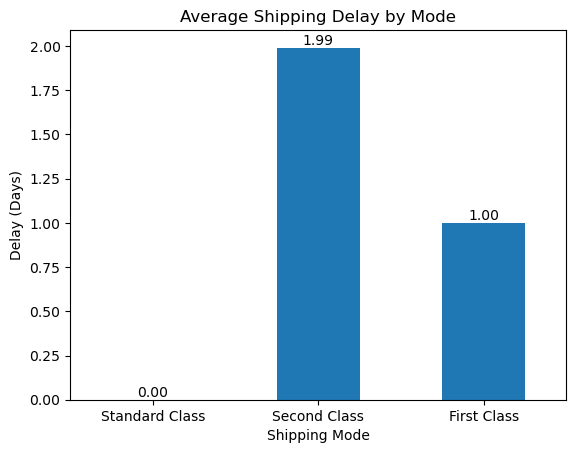

In [131]:
#30

delay_by_mode = dataset.groupby('Shipping Mode', observed=True)['Shipping Delay'].mean().round(2)

ax = delay_by_mode.plot(kind='bar')

plt.title("Average Shipping Delay by Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Delay (Days)")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt='%.2f')

plt.show()

Chart 2: Average Profit Margin by Market

- This chart shows how profitability varies across different markets.
- Africa has the highest average profit margin, while Pacific Asia has the lowest.
- The relatively small differences suggest that profitability is fairly consistent across regions with slight variations.

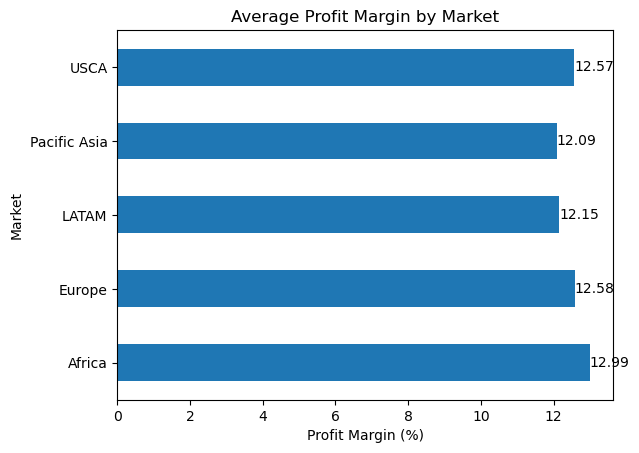

In [132]:
#31

profit_by_market = dataset.groupby('Market', observed=True)['Profit Margin'].mean().round(2)

ax = profit_by_market.plot(kind='barh')

plt.title("Average Profit Margin by Market")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Market")

ax.bar_label(ax.containers[0], fmt='%.2f')

plt.show()

Chart 3: Order Volume Heatmap (Market vs Shipping Mode)

- This heatmap shows the number of orders for each combination of market and shipping mode, allowing comparison across two dimensions at once.
- Standard Class has the highest order volume across all markets, indicating it is the most preferred shipping option.
- First Class has significantly lower usage, suggesting customers tend to prioritize cost over faster delivery.

C:\Users\user\AppData\Local\Temp\ipykernel_3416\2744567839.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = dataset.pivot_table(


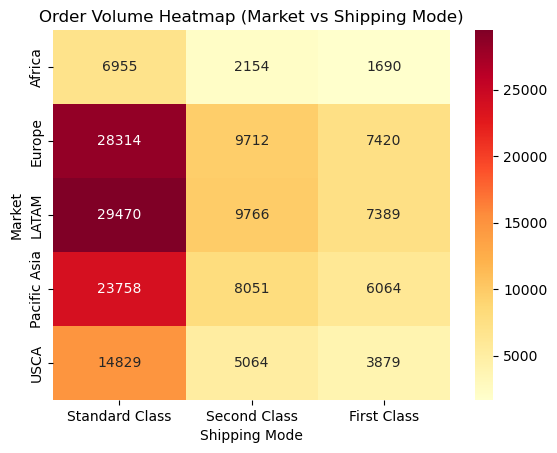

In [130]:
#32

pivot = dataset.pivot_table(
    index='Market',
    columns='Shipping Mode',
    values='Sales',
    aggfunc='count'
)

sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd')

plt.title("Order Volume Heatmap (Market vs Shipping Mode)")
plt.xlabel("Shipping Mode")
plt.ylabel("Market")

plt.show()

Chart 4: Distribution of Order Profit per Order

- This histogram shows how profit per order is distributed across all transactions.
- Most orders generate moderate positive profit, with values concentrated between 0 and 60 USD.
- A smaller number of negative values indicates loss-making orders, while a gradual decline at higher values suggests fewer high-profit transactions.

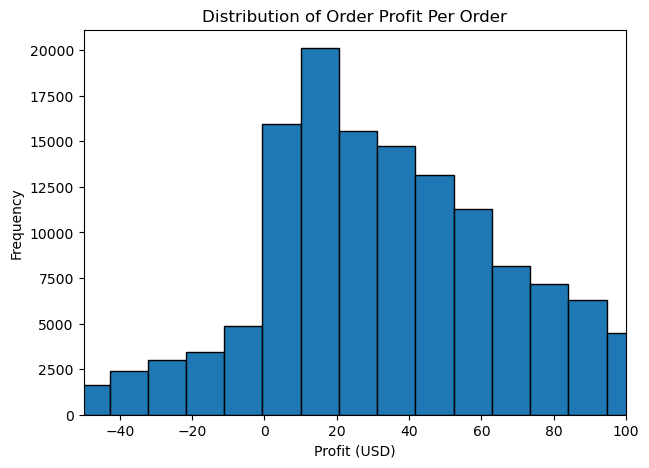

In [140]:
#33

plt.figure(figsize=(7,5))

dataset['Order Profit Per Order'].plot(
    kind='hist',
    bins=40,
    edgecolor='black'
)

plt.title("Distribution of Order Profit Per Order")
plt.xlabel("Profit (USD)")
plt.ylabel("Frequency")

plt.xlim(-50, 100)

plt.show()